In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# 1. Загрузка и первичный анализ

In [2]:
# 1. Загрузка
df = pd.read_csv('Task 2 - Step 2 Cloude Data (1800 rows).csv', encoding='cp1252')
display(df.head(5))
display(df.shape)

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,hook_type,hook_length_words,curiosity_gap,emotional_intensity_hook,...,proof_type,language,conversational_score,pronoun_you_count,avg_sentence_length_words,sentiment_trajectory,emotion_shift_after_hook,key_idea,concept_cluster,error
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",contrarian,28.0,yes,high,...,testimonial,English,very_high,6.0,14.2,Confident and bold opening â†’ dismissive of t...,Shifts from defiant confidence to helpful educ...,Work smarter not harder by using digestive enz...,Health/Wellness Supplement Marketing,NaN
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,story,24.0,yes,high,...,testimonial,Spanish,very_high,8.0,18.5,Negative to positive: starts with love-hate co...,From conflicted (love/hate) to empowered (feel...,Gummy supplements that improve digestion and c...,"Health/Wellness supplements, digestive aids",NaN
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",problem,28.0,yes,high,...,mixed,Spanish,very_high,8.0,14.2,Negative (fake products) â†’ Positive (solutio...,Shifts from frustration with false alternative...,This authentic fiber gummy provides the digest...,Health & Wellness - Digestive Aid,NaN
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,contrarian,34.0,yes,high,...,mixed,English,very_high,8.0,12.3,Confident opening â†’ Curious questioning â†’ ...,Shifts from defiant confidence to genuine curi...,Gut health through digestive enzymes and probi...,Health/Wellness supplement promotion with pers...,NaN
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,problem,42.0,yes,high,...,mixed,Spanish,very_high,15.0,18.5,negative (constipation problem) â†’ positive (...,"Shifts from frustration and urgency to relief,...",Digestive enzymes can break down all foods and...,health_wellness_digestive,NaN


(1801, 29)

In [3]:
# Обрабатываем пустые значения
df = df[df['error'] != "failed"]
df = df.reset_index(drop=True)
display(df.shape)

(1799, 29)

In [4]:
df.columns

Index(['URL', 'Video Revenue', 'Views Count', 'Likes Count', 'Comments Count',
       'Transcript', 'hook_type', 'hook_length_words', 'curiosity_gap',
       'emotional_intensity_hook', 'product_in_hook', 'time_to_product',
       'time_to_payoff', 'narrative_structure', 'open_loop',
       'selling_points_count', 'selling_point_density',
       'benefit_feature_ratio', 'mechanism_present', 'proof_type', 'language',
       'conversational_score', 'pronoun_you_count',
       'avg_sentence_length_words', 'sentiment_trajectory',
       'emotion_shift_after_hook', 'key_idea', 'concept_cluster', 'error'],
      dtype='object')

# 2. Добавляем целевую колонку для предсказаний

In [5]:
# Определяем границы (bins) и названия категорий (labels)
bins = [0, 0.001, 1000, 10000, np.inf]
labels = ['Zero', 'Low', 'Mid', 'High']

# Создаем колонку (right=False делает интервал [0, 1000), т.е. до 999 включительно)
df['revenue_category'] = pd.cut(df['Video Revenue'], bins=bins, labels=labels, right=False)
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,hook_type,hook_length_words,curiosity_gap,emotional_intensity_hook,...,language,conversational_score,pronoun_you_count,avg_sentence_length_words,sentiment_trajectory,emotion_shift_after_hook,key_idea,concept_cluster,error,revenue_category
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",contrarian,28.0,yes,high,...,English,very_high,6.0,14.2,Confident and bold opening â†’ dismissive of t...,Shifts from defiant confidence to helpful educ...,Work smarter not harder by using digestive enz...,Health/Wellness Supplement Marketing,NaN,High
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,story,24.0,yes,high,...,Spanish,very_high,8.0,18.5,Negative to positive: starts with love-hate co...,From conflicted (love/hate) to empowered (feel...,Gummy supplements that improve digestion and c...,"Health/Wellness supplements, digestive aids",NaN,High
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",problem,28.0,yes,high,...,Spanish,very_high,8.0,14.2,Negative (fake products) â†’ Positive (solutio...,Shifts from frustration with false alternative...,This authentic fiber gummy provides the digest...,Health & Wellness - Digestive Aid,NaN,High
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,contrarian,34.0,yes,high,...,English,very_high,8.0,12.3,Confident opening â†’ Curious questioning â†’ ...,Shifts from defiant confidence to genuine curi...,Gut health through digestive enzymes and probi...,Health/Wellness supplement promotion with pers...,NaN,High
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,problem,42.0,yes,high,...,Spanish,very_high,15.0,18.5,negative (constipation problem) â†’ positive (...,"Shifts from frustration and urgency to relief,...",Digestive enzymes can break down all foods and...,health_wellness_digestive,NaN,High


In [6]:
share = df['revenue_category'].value_counts(normalize=True)*100
share

Low     49.360756
Zero    43.135075
Mid      6.448027
High     1.056142
Name: revenue_category, dtype: float64

In [7]:
feature_names = ['hook_type', 'hook_length_words', 'curiosity_gap',
       'emotional_intensity_hook', 'product_in_hook', 'time_to_product',
       'time_to_payoff', 'narrative_structure', 'open_loop',
       'selling_points_count', 'selling_point_density',
       'benefit_feature_ratio', 'mechanism_present', 'proof_type', 'language',
       'conversational_score', 'pronoun_you_count',
       'avg_sentence_length_words']

In [8]:
target_name = 'revenue_category'

# 3. Преобразование признаков (Preprocessing)

In [13]:
# Правильный порядок классов
target_mapping = {'Zero': 0, 'Low': 1, 'Mid': 2, 'High': 3}
class_names = ['Zero', 'Low', 'Mid', 'High']

# Применяем маппинг
df['target_encoded'] = df[target_name].map(target_mapping)
df.head()

,URL,Video Revenue,Views Count,Likes Count,Comments Count,Transcript,hook_type,hook_length_words,curiosity_gap,emotional_intensity_hook,...,conversational_score,pronoun_you_count,avg_sentence_length_words,sentiment_trajectory,emotion_shift_after_hook,key_idea,concept_cluster,error,revenue_category,target_encoded
0,https://tiktok.com/@_naturalhealing/video/7586...,236751.0,19921607,418442,1918,"And at the end of the day, I'm still gonna loo...",contrarian,28.0,yes,high,...,very_high,6.0,14.2,Confident and bold opening â†’ dismissive of t...,Shifts from defiant confidence to helpful educ...,Work smarter not harder by using digestive enz...,Health/Wellness Supplement Marketing,NaN,High,3
1,https://tiktok.com/@that.girl.wellnesstips/vid...,49453.1,1712754,4749,133,A la muchacha del video que public?? que comer...,story,24.0,yes,high,...,very_high,8.0,18.5,Negative to positive: starts with love-hate co...,From conflicted (love/hate) to empowered (feel...,Gummy supplements that improve digestion and c...,"Health/Wellness supplements, digestive aids",NaN,High,3
2,https://tiktok.com/@that.girl.wellnesstips/vid...,39347.4,664058,1143,34,"Falsas, falsas, falsas, falsas, falsas y ningu...",problem,28.0,yes,high,...,very_high,8.0,14.2,Negative (fake products) â†’ Positive (solutio...,Shifts from frustration with false alternative...,This authentic fiber gummy provides the digest...,Health & Wellness - Digestive Aid,NaN,High,3
3,https://tiktok.com/@shopbyjake/video/758832470...,27731.6,1169546,7539,152,As at the end of the day I'mma stay looking li...,contrarian,34.0,yes,high,...,very_high,8.0,12.3,Confident opening â†’ Curious questioning â†’ ...,Shifts from defiant confidence to genuine curi...,Gut health through digestive enzymes and probi...,Health/Wellness supplement promotion with pers...,NaN,High,3
4,https://tiktok.com/@tips.de.suplement/video/75...,24151.9,2093968,6908,176,Si tienes atorado en el intestino hasta lo que...,problem,42.0,yes,high,...,very_high,15.0,18.5,negative (constipation problem) â†’ positive (...,"Shifts from frustration and urgency to relief,...",Digestive enzymes can break down all foods and...,health_wellness_digestive,NaN,High,3


In [14]:
X = df[feature_names].copy()

# Кодируем текстовые признаки в числа
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

print("Данные готовы к анализу.")
X.head()

Данные готовы к анализу.


,hook_type,hook_length_words,curiosity_gap,emotional_intensity_hook,product_in_hook,time_to_product,time_to_payoff,narrative_structure,open_loop,selling_points_count,selling_point_density,benefit_feature_ratio,mechanism_present,proof_type,language,conversational_score,pronoun_you_count,avg_sentence_length_words
0,4,28.0,1,0,0,2,1,21,1,5.0,0.12,1,1,6,0,3,6.0,14.2
1,20,24.0,1,0,0,1,2,24,1,5.0,0.12,1,1,6,3,3,8.0,18.5
2,11,28.0,1,0,0,2,1,21,1,5.0,0.18,1,1,1,3,3,8.0,14.2
3,4,34.0,1,0,0,2,3,24,1,4.0,0.18,1,1,1,0,3,8.0,12.3
4,11,42.0,1,0,0,2,1,21,1,8.0,0.12,1,1,1,3,3,15.0,18.5


# 4. Корреляция с целевой колонкой

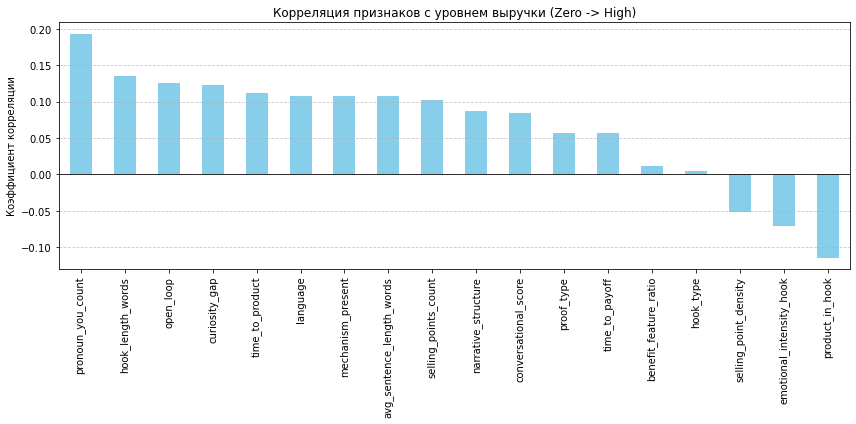

Топ признаков по корреляции:
pronoun_you_count            0.193480
hook_length_words            0.135718
open_loop                    0.125711
curiosity_gap                0.122899
time_to_product              0.112004
language                     0.107591
mechanism_present            0.107501
avg_sentence_length_words    0.107268
selling_points_count         0.101780
narrative_structure          0.087418
conversational_score         0.085064
proof_type                   0.057617
time_to_payoff               0.057314
benefit_feature_ratio        0.012222
hook_type                    0.004529
selling_point_density       -0.051475
emotional_intensity_hook    -0.071025
product_in_hook             -0.114364
Name: target, dtype: float64


In [17]:
# Создаем временный DF для корреляции

# Оставляем в X только колонки, которые уже стали числами
X_numeric = X.select_dtypes(include=[np.number])

# Создаем временный DF
corr_df = X_numeric.copy()

# преобразуем категорию в число (float)
corr_df['target'] = df['target_encoded'].astype(float).values

# считаем корреляцию
matrix = corr_df.corr()

if 'target' in matrix.columns:
    # Сортируем и убираем саму колонку target из графика
    correlations = matrix['target'].sort_values(ascending=False).drop('target', errors='ignore')
    
    plt.figure(figsize=(12, 6))
    correlations.plot(kind='bar', color='skyblue')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title("Корреляция признаков с уровнем выручки (Zero -> High)")
    plt.ylabel("Коэффициент корреляции")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("Топ признаков по корреляции:")
    print(correlations.head(20))
else:
    print("Ошибка. Типы данных в corr_df:")
    print(corr_df.dtypes)

# 5. Подготовка, SMOTE и Обучение

In [18]:
# 1. Окончательная подготовка признаков и таргета
# Убеждаемся, что таргет — это целые числа
y = df['target_encoded'].astype(int)
class_names = ['Zero', 'Low', 'Mid', 'High']

# 2. Разделение на обучающую и тестовую выборки (80/20)
# stratify=y гарантирует, что в тесте будет тот же % High, что и в оригинале
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Обработка дисбаланса классов
# Создаем синтетические примеры для редких классов (High и Mid)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Инициализация и обучение Random Forest
# class_weight='balanced' дает дополнительный вес редким классам
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced'
)
rf_model.fit(X_train_res, y_train_res)

print("Модель успешно обучена на сбалансированных данных.")

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\arrays\categorical.py:528: RuntimeWarning: invalid value encountered in cast
  fill_value = lib.item_from_zerodim(np.array(np.nan).astype(dtype))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Модель успешно обучена на сбалансированных данных.


# 6. Оценка качества

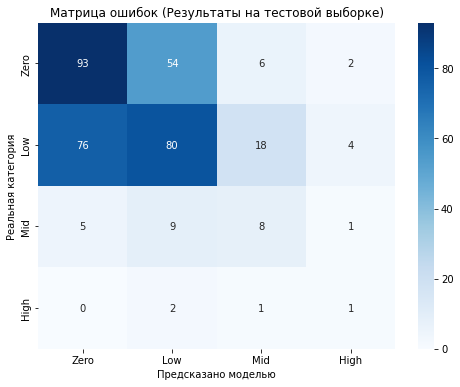


Детальный отчет по метрикам:
              precision    recall  f1-score   support

        Zero       0.53      0.60      0.57       155
         Low       0.55      0.45      0.50       178
         Mid       0.24      0.35      0.29        23
        High       0.12      0.25      0.17         4

    accuracy                           0.51       360
   macro avg       0.36      0.41      0.38       360
weighted avg       0.52      0.51      0.51       360

Итоговый Weighted F1-Score: 0.5084


In [20]:
# Предсказания
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Матрица ошибок (Результаты на тестовой выборке)')
plt.xlabel('Предсказано моделью')
plt.ylabel('Реальная категория')
plt.show()

# Подробный отчет (F1-Score, Precision, Recall)
print("\nДетальный отчет по метрикам:")
print(classification_report(y_test, y_pred, target_names=class_names))

weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Итоговый Weighted F1-Score: {weighted_f1:.4f}")

# 7. Важность признаков (Feature Importance)

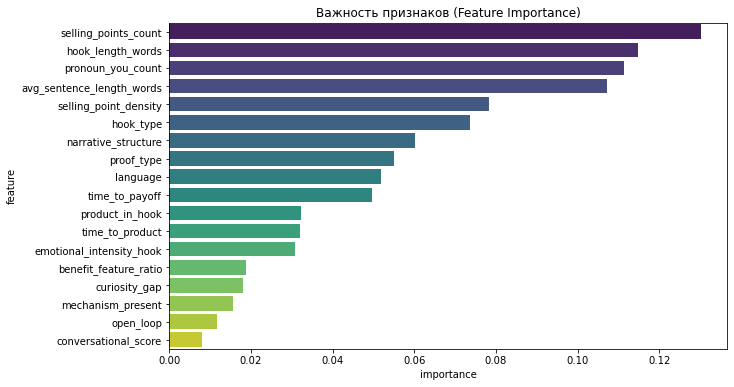

In [21]:
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
plt.title('Важность признаков (Feature Importance)')
plt.show()

# 8. Confidence Score (Уверенность модели)

In [22]:
# Собираем данные по индексам тестовой выборки
results = df.loc[X_test.index, ['URL', 'Video Revenue', 'Transcript']].copy()

# Добавляем результаты модели
results['Real_Category'] = [class_names[i] for i in y_test]
results['Predicted_Category'] = [class_names[i] for i in y_pred]

# Добавляем уверенность (Probability Score)
# np.max берет вероятность самого вероятного класса для каждой строки
results['Confidence_Score'] = np.max(y_probs, axis=1)

# Сортируем: сначала самые "уверенные" предсказания
results = results.sort_values(by='Confidence_Score', ascending=False)

# Выводим примеры, где модель предсказала High или Mid
high_potential = results[results['Predicted_Category'].isin(['High', 'Mid'])]
print(f"Найдено {len(high_potential)} видео с высоким потенциалом выручки.")
display(high_potential.head(10))

# По желанию сохраняем в файл
# results.to_excel('predictions_analysis.xlsx', index=False)

Найдено 41 видео с высоким потенциалом выручки.


,URL,Video Revenue,Transcript,Real_Category,Predicted_Category,Confidence_Score
416,https://tiktok.com/@anagonzalez8736/video/7589...,97.16,"Antes, despu?Â©s.\nAntes, despu?Â©s.\nSi t?? e...",Low,High,0.708890
449,https://tiktok.com/@tips.de.suplement/video/75...,86.32,"Â¬Ã¸Tienes ganas de ir a hacerte el dos as??, ...",Low,Mid,0.627210
1087,https://tiktok.com/@saleswithbonnie/video/7581...,0.00,Pack an order with me Break it down,Zero,Mid,0.607451
121,https://tiktok.com/@luxurious.listing/video/75...,1206.95,remember that it's alright alright alright\nda...,Mid,Mid,0.596707
1212,https://tiktok.com/@that.girl.wellnesstips/vid...,0.00,Me vaci?? el intestino y me aplano la panza! ?...,Zero,Mid,0.586651
69,https://tiktok.com/@palomaashop/video/75801986...,2501.42,Les voy a compartir mi secreto de c??mo hago y...,Mid,Mid,0.583848
139,https://tiktok.com/@that.girl.wellnesstips/vid...,952.05,Si tienes atorado en el intestino hasta lo que...,Low,High,0.551620
861,https://tiktok.com/@that.girl.wellnesstips/vid...,23.08,Como aplane mi panza en dos pasos simples\nLo ...,Low,Mid,0.503379
503,https://tiktok.com/@alinasfinds/video/75772340...,69.00,Nobody gonna love me better\nI'mma stick with ...,Low,Mid,0.496498
131,https://tiktok.com/@tips.de.suplement/video/75...,1056.52,Si quieres hacer del ba?Â±o de la popo as?? gr...,Mid,Mid,0.492082
